In [1]:
import numpy as np
import pandas as pd
import mglearn
import matplotlib.pyplot as plt

## RandomForest

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

In [3]:
X, y = make_moons(n_samples=100, noise=0.25, random_state=3)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,
                                                    random_state=42)

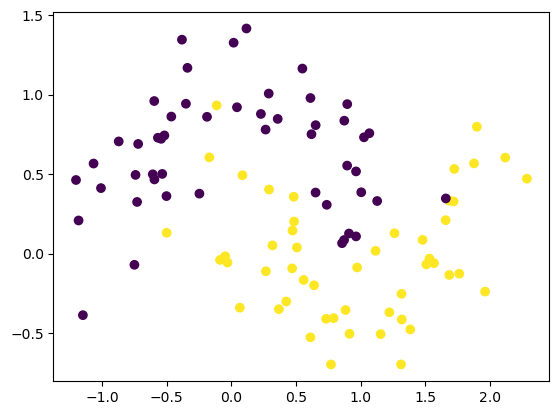

In [4]:
plt.scatter(X[:,0], X[:,1], c= y)

In [5]:
forest = RandomForestClassifier(n_estimators=5, random_state=2)
forest.fit(X_train, y_train)

RandomForestClassifier(n_estimators=5, random_state=2)

In [6]:
forest.estimators_

[DecisionTreeClassifier(max_features='sqrt', random_state=1872583848),
 DecisionTreeClassifier(max_features='sqrt', random_state=794921487),
 DecisionTreeClassifier(max_features='sqrt', random_state=111352301),
 DecisionTreeClassifier(max_features='sqrt', random_state=1853453896),
 DecisionTreeClassifier(max_features='sqrt', random_state=213298710)]

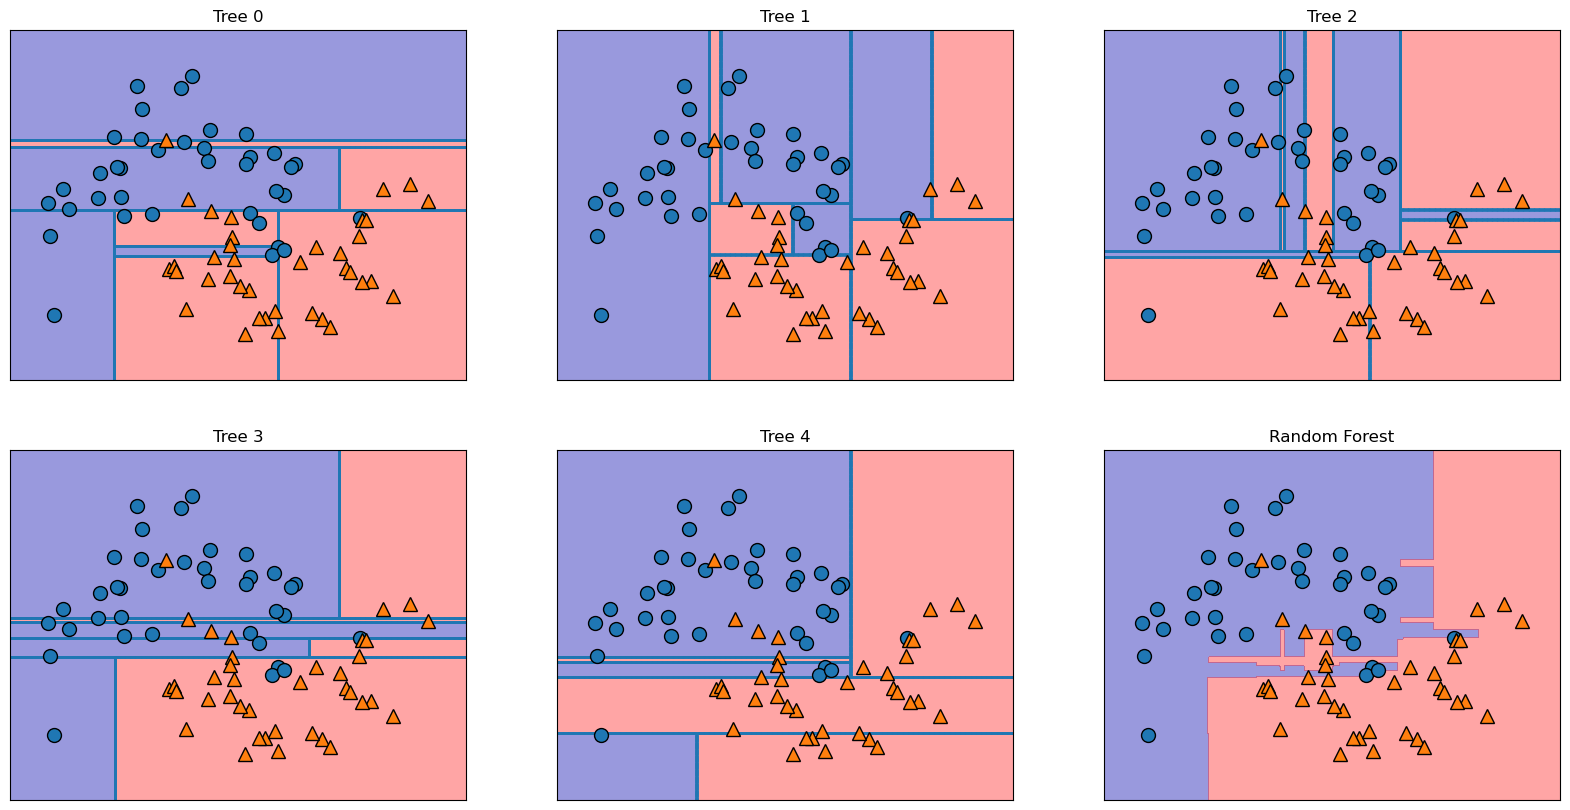

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
for i, (ax, tree) in enumerate(zip(axes.ravel(), forest.estimators_)):
    ax.set_title("Tree {}".format(i))
    mglearn.plots.plot_tree_partition(X_train, y_train, tree, ax=ax)
    
mglearn.plots.plot_2d_separator(forest, X_train, fill=True, ax=axes[-1, -1],
                                alpha=.4)
axes[-1, -1].set_title("Random Forest")
mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train)

In [8]:
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score

In [9]:
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=0)

In [10]:
training_accuracy = []
test_accuracy = []

n_settings = [1, 2, 5, 10, 20, 50, 100]
for n in n_settings:
    clf = RandomForestClassifier(n_estimators=n)
    clf.fit(X_train, y_train)
    
    y_train_hat = clf.predict(X_train)
    y_test_hat = clf.predict(X_test)
    
    training_accuracy.append(accuracy_score(y_train, y_train_hat))
    test_accuracy.append(accuracy_score(y_test, y_test_hat))

In [11]:
pd.DataFrame({"n_estimators":n_settings, "training accuracy": training_accuracy, "test accuracy": test_accuracy})

,n_estimators,training accuracy,test accuracy
0,1,0.962441,0.916084
1,2,0.976526,0.909091
2,5,0.992958,0.958042
3,10,1.000000,0.944056
4,20,1.000000,0.951049
5,50,1.000000,0.958042
6,100,1.000000,0.958042


#### theoretically, more trees lead to stable model. 

#### how about scaling ?

### feature importance

In [12]:
clf = RandomForestClassifier(n_estimators=100, random_state=0)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [13]:
clf.feature_importances_

array([0.02969122, 0.01720923, 0.06929807, 0.04112995, 0.00500449,
       0.00636883, 0.08056202, 0.09200666, 0.00435231, 0.0042842 ,
       0.02136349, 0.00420529, 0.01354811, 0.02303752, 0.00288949,
       0.00593161, 0.00468708, 0.0027883 , 0.003081  , 0.00229185,
       0.12542246, 0.01704882, 0.19536571, 0.0743788 , 0.00948886,
       0.0086519 , 0.02172119, 0.10149821, 0.00399358, 0.00869974])

In [14]:
def plot_feature_importances_cancer(model):
    n_features = cancer.data.shape[1]
    plt.barh(np.arange(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), cancer.feature_names)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.ylim(-1, n_features)

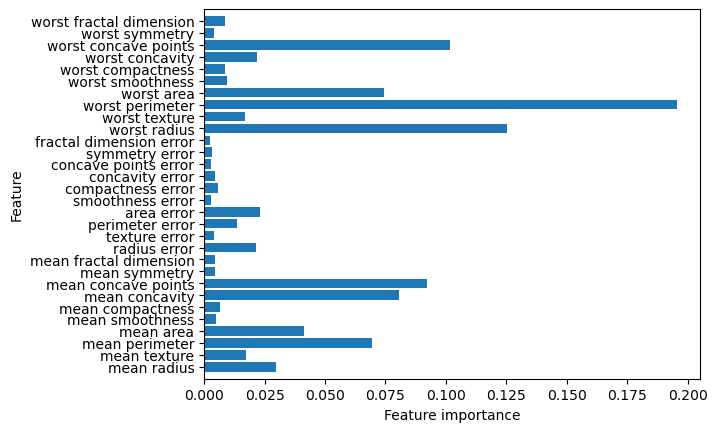

In [15]:
plot_feature_importances_cancer(clf)

## Adaboost

In [16]:
X, y = make_moons(n_samples=100, noise=0.25, random_state=3)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,
                                                    random_state=42)

In [17]:
from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier(n_estimators=5, random_state=42)
ada.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=5, random_state=42)

In [18]:
ada.estimators_

[DecisionTreeClassifier(max_depth=1, random_state=1608637542),
 DecisionTreeClassifier(max_depth=1, random_state=1273642419),
 DecisionTreeClassifier(max_depth=1, random_state=1935803228),
 DecisionTreeClassifier(max_depth=1, random_state=787846414),
 DecisionTreeClassifier(max_depth=1, random_state=996406378)]

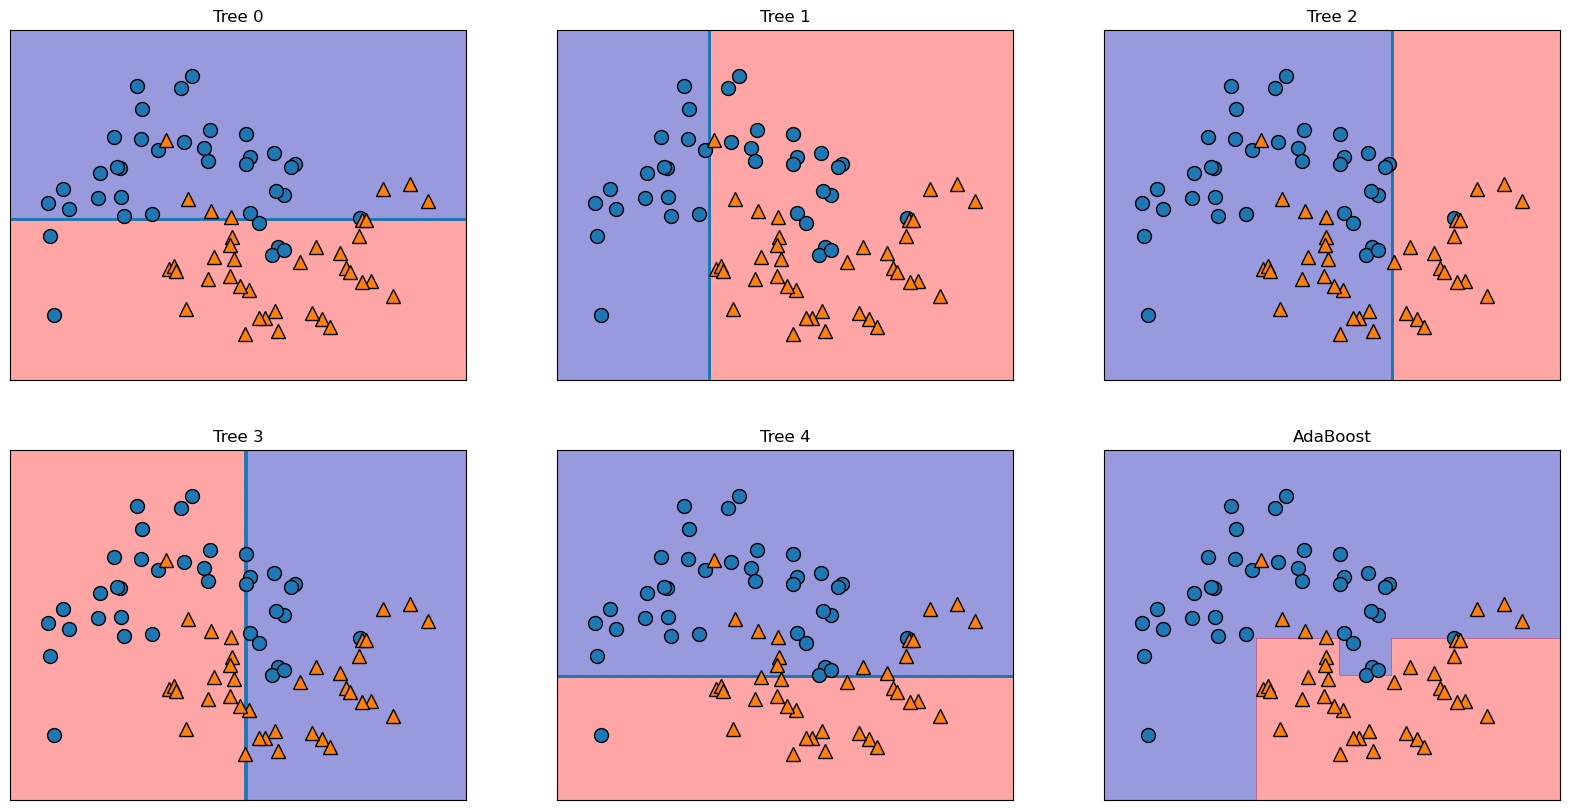

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
for i, (ax, tree) in enumerate(zip(axes.ravel(), ada.estimators_)):
    ax.set_title("Tree {}".format(i))
    mglearn.plots.plot_tree_partition(X_train, y_train, tree, ax=ax)
    
mglearn.plots.plot_2d_separator(ada, X_train, fill=True, ax=axes[-1, -1], alpha=.4)
axes[-1, -1].set_title("AdaBoost")
mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train)
plt.show()

## Bagging (9 logistic regression models + voting)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=0)

#### training

In [21]:
n_estimators=9

logregs=[]
for i in range(n_estimators):
    ''''TODO - bootstrap sampling (You can use 'np.random.choice')'''
    np.random.seed(1)
    idx = np.random.choice(X_train.shape[0], X_train.shape[0], replace = True)
    X_train_base = X_train[idx,:]
    y_train_base = y_train[idx]
    logregs.append(LogisticRegression().fit(X_train_base, y_train_base))  

C:\Users\oms83\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\oms83\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

#### test

In [22]:
y_test_hats=[]
for i in range(n_estimators):
    '''TODO - get y_test_hat of each base model'''
    y_test_hat = logregs[i].predict(X_test)
    
    y_test_hats.append(y_test_hat)    
y_test_hats = np.stack(y_test_hats).T

In [23]:
y_test_hats

array([[1, 1, 1, ..., 1, 1, 1],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [1, 1, 1, ..., 1, 1, 1],
       [0, 0, 0, ..., 0, 0, 0]])

In [24]:
y_test_hats.shape

(143, 9)

In [28]:
from scipy import stats
'''TODO - use 'stats.mode' function to get the result of majority voting

'''
y_test_hat_voted = stats.mode(y_test_hats, axis = 1)[0].squeeze() 
    

In [29]:
accuracy_score(y_test, y_test_hat_voted)

0.9370629370629371

In [30]:
# accuracy of each logistic regression model
for i in range(n_estimators):
    print(accuracy_score(y_test, y_test_hats[:,i]))

0.9370629370629371
0.9370629370629371
0.9370629370629371
0.9370629370629371
0.9370629370629371
0.9370629370629371
0.9370629370629371
0.9370629370629371
0.9370629370629371
